# Notebook 08b: LSTM Authenticator on CL Backbone

This notebook trains the pairwise LSTM authenticator on top of the CL-trained CNN encoder from NB08a. The architecture is identical to NB03 (CNNfix+LSTM), with the key difference that the frozen CNN backbone was trained in a class-incremental continual learning setting rather than on all subjects at once.

```
NB02 + NB03:  GaitCNN (single task, 98 subjects)  →  AuthModel (LSTM)
NB08a + here: GaitCNN (4 CL tasks, 96 subjects)  →  AuthModel (LSTM)
```

Two authenticators are trained, one for each CL backbone:

- **auth_std**: built on the naive fine-tuning backbone (only remembers task 3)
- **auth_cdml**: built on the CDML backbone (remembers all four tasks)

The CNN is frozen in both cases. Only the LSTM and FC head are trained (83,074 parameters).

The authentication pairs come from a dedicated dataset generated for the 96 CL member subjects. Non-member test pairs are drawn from the 22 held-out subjects (20 original non-members plus 2 leftover members not assigned to any task).

The trained authenticators are saved to `checkpoints/whuGAIT/cl8/` and loaded by NB08c for the membership inference attack.

## Why the CNN backbone is frozen

The membership inference signal analysed in NB08c is attributed to Phase 1 (CNN identification training). Freezing the CNN ensures that the LSTM training does not alter the representations produced by the CL backbone, so any MIA signal observed in NB08c reflects Phase 1 memorisation rather than Phase 2 fine-tuning.

This design choice also makes the comparison between std and CDML backbones clean: both LSTMs are trained identically, and any difference in MIA AUC is due to the difference in the underlying feature representations.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')

import json, time, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam

from src.models.gait_cnn   import GaitCNN
from src.models.cl_cnn     import CDMLGaitCNN
from src.models.auth_model import AuthModel
from src.data.dataset      import load_dataset, filter_subjects, normalize
from src.data.pair_builder import build_auth_pairs

# ── config ──
N_TASKS           = 4
SUBJECTS_PER_TASK = 24
N_CLASSES         = N_TASKS * SUBJECTS_PER_TASK   # 96
EPOCHS_LSTM       = 10
LR_LSTM           = 0.0025
WEIGHT_DECAY      = 0.0015
DROPOUT           = 0.3
BATCH_SIZE        = 512
N_PAIRS_TRAIN     = 33000
N_PAIRS_TEST      = 3800
SEED_BASE         = 1000
DEVICE            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DATA_ROOT    = Path('../data')
ARTIFACT_DIR = Path('../artifacts/whuGAIT')
CKPT_DIR     = Path('../checkpoints/whuGAIT/cl8')
RESULT_DIR   = Path('../results/whuGAIT')

log = logging.getLogger('nb08b')
log.setLevel(logging.INFO)
log.handlers.clear()
log.addHandler(logging.StreamHandler())

log.info(f'Device: {DEVICE}')

Device: cpu


## 1. Data loading

In [3]:
with open(ARTIFACT_DIR / 'subject_split.json') as f:
    split = json.load(f)

all_member_ids    = sorted(split['train_ids'])
all_nonmember_ids = sorted(split['held_out_ids'])
member_ids    = all_member_ids[:N_TASKS * SUBJECTS_PER_TASK]
leftover_ids  = all_member_ids[N_TASKS * SUBJECTS_PER_TASK:]
nonmember_ids = all_nonmember_ids + leftover_ids

X_raw_tr, y_raw_tr = load_dataset(str(DATA_ROOT / 'Dataset #1'), 'train')
X_mem_tr, _        = filter_subjects(X_raw_tr, y_raw_tr, member_ids)
_, norm_stats       = normalize(X_mem_tr)
X_tr, _ = normalize(X_raw_tr, norm_stats)
X_d2, y_d2  = load_dataset(str(DATA_ROOT / 'Dataset #2'), 'train')
X_d2n, _    = normalize(X_d2, norm_stats)

print(f'Members: {len(member_ids)}  |  Non-members (incl. leftover): {len(nonmember_ids)}')

Members: 96  |  Non-members (incl. leftover): 22


## 2. Authentication pair generation

Pairs are built with `build_auth_pairs`: for each draw, two windows from the same subject form a genuine pair (label 0), and one window each from two different subjects form an impostor pair (label 1). This matches the label convention in Dataset #5 (NB03).

- **Train pairs**: drawn from the 96 member subjects (Dataset #1 training windows)
- **Test pairs**: drawn from the 22 non-member subjects (Dataset #2 windows)

Pairs are saved to `auth_pairs_cl.npz` and reloaded on subsequent runs.

In [4]:
pairs_path = CKPT_DIR / 'auth_pairs_cl.npz'

if pairs_path.exists():
    log.info('Loading existing pairs...')
    d = np.load(pairs_path)
    X1_tr, X2_tr, y_tr, s1_tr, s2_tr = d['X1_tr'], d['X2_tr'], d['y_tr'], d['s1_tr'], d['s2_tr']
    X1_te, X2_te, y_te, s1_te, s2_te = d['X1_te'], d['X2_te'], d['y_te'], d['s1_te'], d['s2_te']
else:
    log.info('Building pairs...')
    mask_mem = np.isin(y_raw_tr, member_ids)
    X1_tr, X2_tr, y_tr, s1_tr, s2_tr = build_auth_pairs(
        X_tr[mask_mem].astype(np.float32), y_raw_tr[mask_mem], N_PAIRS_TRAIN, seed=42)
    mask_nm = np.isin(y_d2, nonmember_ids)
    X1_te, X2_te, y_te, s1_te, s2_te = build_auth_pairs(
        X_d2n[mask_nm].astype(np.float32), y_d2[mask_nm], N_PAIRS_TEST, seed=43)
    np.savez_compressed(pairs_path,
        X1_tr=X1_tr, X2_tr=X2_tr, y_tr=y_tr, s1_tr=s1_tr, s2_tr=s2_tr,
        X1_te=X1_te, X2_te=X2_te, y_te=y_te, s1_te=s1_te, s2_te=s2_te)
    log.info(f'Pairs saved to {pairs_path}')

def pair_loader(X1, X2, y, shuffle=True):
    return DataLoader(
        TensorDataset(torch.from_numpy(X1).float(),
                      torch.from_numpy(X2).float(),
                      torch.from_numpy(y).long()),
        batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader = pair_loader(X1_tr, X2_tr, y_tr)
test_loader  = pair_loader(X1_te, X2_te, y_te, shuffle=False)

print(f'Train pairs: {len(y_tr)}  same={int((y_tr==0).sum())}  diff={int((y_tr==1).sum())}')
print(f'Test  pairs: {len(y_te)}  same={int((y_te==0).sum())}  diff={int((y_te==1).sum())}')

Loading existing pairs...


Train pairs: 66000  same=33000  diff=33000
Test  pairs: 7600  same=3800  diff=3800


In [5]:
from src.data.pair_builder import build_cross_pairs

_pairs_path = CKPT_DIR / 'auth_pairs_cl.npz'
_d = dict(np.load(_pairs_path))

if 'X1_mn' not in _d:
    log.info('Building MN/NM cross pairs and appending to auth_pairs_cl.npz ...')
    _N_CROSS = 3800   # ~same size as the NN test set split evenly across MN and NM

    _mask_mem = np.isin(y_raw_tr, member_ids)
    _X_mem    = X_tr[_mask_mem].astype(np.float32)
    _y_mem    = y_raw_tr[_mask_mem]

    _mask_nm  = np.isin(y_d2, nonmember_ids)
    _X_nm     = X_d2n[_mask_nm].astype(np.float32)
    _y_nm     = y_d2[_mask_nm]

    (X1_mn, X2_mn, y_mn, s1_mn, s2_mn,
     X1_nm, X2_nm, y_nm, s1_nm, s2_nm) = build_cross_pairs(
        _X_mem, _y_mem, _X_nm, _y_nm, n_pairs_per_case=_N_CROSS, seed=44)

    _d.update(dict(
        X1_mn=X1_mn, X2_mn=X2_mn, y_mn=y_mn, s1_mn=s1_mn, s2_mn=s2_mn,
        X1_nm=X1_nm, X2_nm=X2_nm, y_nm=y_nm, s1_nm=s1_nm, s2_nm=s2_nm,
    ))
    np.savez_compressed(_pairs_path, **_d)
    log.info(f'Cross pairs saved: MN={len(y_mn)}  NM={len(y_nm)}')
    print(f'Cross pairs saved: MN={len(y_mn)}  NM={len(y_nm)}')
else:
    log.info('Cross pairs already present in auth_pairs_cl.npz — skipping.')
    print('Cross pairs already present — skipping.')

Building MN/NM cross pairs and appending to auth_pairs_cl.npz ...


Cross pairs saved: MN=3800  NM=3800


Cross pairs saved: MN=3800  NM=3800


## 3. LSTM training

For each backbone (std, cdml), an `AuthModel` is built around the frozen CL encoder. The LSTM takes as input the feature maps from `get_feature_maps()`, which taps after conv4 of the frozen CNN (shape $B \times 16 \times 128$ per window). The two windows are concatenated along the channel axis before being fed to the LSTM.

Note that the CDML code $s_k$ is applied after the flatten layer, downstream of `get_feature_maps()`. The LSTM therefore operates on unmodulated feature maps in both the std and cdml cases. Any difference in authentication accuracy or MIA signal between the two backbones reflects differences in the CNN weights themselves, not the code.

In [6]:
criterion = nn.CrossEntropyLoss()
lstm_history = {}

for label in ['std', 'cdml']:
    auth_ckpt = CKPT_DIR / f'auth_{label}.pt'

    if label == 'std':
        backbone = GaitCNN(N_CLASSES)
    else:
        backbone = CDMLGaitCNN(N_CLASSES)
        for k in range(N_TASKS):
            backbone.register_code(k, SEED_BASE + k)

    backbone.load_state_dict(torch.load(
        CKPT_DIR / f'{label}_task{N_TASKS-1}.pt', map_location=DEVICE))

    auth = AuthModel(cnn_encoder=backbone, dropout=DROPOUT).to(DEVICE)
    for p in auth.cnn.parameters():
        p.requires_grad = False

    n_frozen    = sum(p.numel() for p in auth.parameters() if not p.requires_grad)
    n_trainable = sum(p.numel() for p in auth.parameters() if p.requires_grad)
    log.info(f'[{label}] Trainable: {n_trainable:,}  Frozen (CNN): {n_frozen:,}')

    if auth_ckpt.exists():
        log.info(f'[{label}] checkpoint found, loading...')
        auth.load_state_dict(torch.load(auth_ckpt, map_location=DEVICE))
        lstm_history[label] = {'loaded': True}
        continue

    optim = Adam(filter(lambda p: p.requires_grad, auth.parameters()),
                 lr=LR_LSTM, weight_decay=WEIGHT_DECAY)
    history = {'train_acc': [], 'test_acc': []}
    best_acc, best_state = 0.0, None
    t0 = time.time()

    for ep in range(1, EPOCHS_LSTM + 1):
        auth.train()
        for x1, x2, yb in train_loader:
            x1, x2, yb = x1.to(DEVICE), x2.to(DEVICE), yb.to(DEVICE)
            optim.zero_grad()
            criterion(auth(x1, x2), yb).backward()
            optim.step()

        auth.eval()
        corr = tot = 0
        with torch.no_grad():
            for x1, x2, yb in test_loader:
                x1, x2, yb = x1.to(DEVICE), x2.to(DEVICE), yb.to(DEVICE)
                corr += (auth(x1, x2).argmax(1) == yb).sum().item()
                tot  += len(yb)
        acc = corr / tot
        history['test_acc'].append(acc)
        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.clone() for k, v in auth.state_dict().items()}
        log.info(f'[{label}] epoch {ep}/{EPOCHS_LSTM}  test_acc={acc*100:.2f}%')

    auth.load_state_dict(best_state)
    torch.save(auth.state_dict(), auth_ckpt)
    lstm_history[label] = {'test_acc': history['test_acc'], 'best_acc': best_acc}
    log.info(f'[{label}] best_acc={best_acc*100:.2f}%  ({time.time()-t0:.0f}s)')

print('LSTM training complete.')

[std] Trainable: 83,074  Frozen (CNN): 326,368


[std] checkpoint found, loading...


[cdml] Trainable: 83,074  Frozen (CNN): 326,368


[cdml] checkpoint found, loading...


LSTM training complete.


## 4. Per-task authentication accuracy

Authentication accuracy is evaluated separately on pairs built from each task's subjects. This shows whether the LSTM authenticator generalises across all four tasks or only the task whose backbone representations are well-preserved.

In [7]:
tasks = [all_member_ids[k*SUBJECTS_PER_TASK:(k+1)*SUBJECTS_PER_TASK] for k in range(N_TASKS)]

def eval_auth_on_pairs(auth, X1, X2, y):
    auth.eval(); corr = tot = 0
    for i in range(0, len(y), BATCH_SIZE):
        x1b = torch.from_numpy(X1[i:i+BATCH_SIZE]).float()
        x2b = torch.from_numpy(X2[i:i+BATCH_SIZE]).float()
        yb  = torch.from_numpy(y[i:i+BATCH_SIZE]).long()
        with torch.no_grad():
            corr += (auth(x1b, x2b).argmax(1) == yb).sum().item()
            tot  += len(yb)
    return corr / tot

# Build per-task pairs from train data (members only)
task_pairs = {}
for k, sids in enumerate(tasks):
    mask = np.isin(y_raw_tr, sids)
    Xk = X_tr[mask].astype(np.float32)
    yk = y_raw_tr[mask]
    X1k, X2k, yk_pairs, _, _ = build_auth_pairs(Xk, yk, n_pairs_per_class=1000, seed=42+k)
    task_pairs[k] = (X1k, X2k, yk_pairs)

print(f'\n{"Task":<8} {"Std LSTM":>10} {"CDML LSTM":>12}')
print('-' * 34)
for label in ['std', 'cdml']:
    if label == 'std':
        backbone = GaitCNN(N_CLASSES)
    else:
        backbone = CDMLGaitCNN(N_CLASSES)
        for k in range(N_TASKS):
            backbone.register_code(k, SEED_BASE + k)
    auth = AuthModel(cnn_encoder=backbone, dropout=DROPOUT)
    auth.load_state_dict(torch.load(CKPT_DIR / f'auth_{label}.pt', map_location=DEVICE))
    auth.eval()
    if label == 'std':
        std_accs = [eval_auth_on_pairs(auth, *task_pairs[k]) for k in range(N_TASKS)]
    else:
        cdml_accs = [eval_auth_on_pairs(auth, *task_pairs[k]) for k in range(N_TASKS)]

for k in range(N_TASKS):
    print(f'Task {k:<4} {std_accs[k]*100:>9.2f}%  {cdml_accs[k]*100:>10.2f}%')
print(f'{"Mean":<8} {np.mean(std_accs)*100:>9.2f}%  {np.mean(cdml_accs)*100:>10.2f}%')


Task       Std LSTM    CDML LSTM
----------------------------------


Task 0        94.85%       95.45%
Task 1        90.45%       89.80%
Task 2        92.85%       92.35%
Task 3        92.00%       93.50%
Mean         92.54%       92.77%


In [8]:
# Persist per-task auth accuracy for the scatter plot in NB08c.
import json as _json

_pt_out = {'std': [float(a) for a in std_accs],
           'cdml': [float(a) for a in cdml_accs]}
with open(RESULT_DIR / 'cl_auth_per_task.json', 'w') as _f:
    _json.dump(_pt_out, _f, indent=2)
print('Saved: results/whuGAIT/cl_auth_per_task.json')

Saved: results/whuGAIT/cl_auth_per_task.json


In [ ]:
# Write LaTeX macros for per-task auth accuracy
import numpy as _np
from datetime import datetime as _dt

_latex_dir = Path('../latex/generated')
_latex_dir.mkdir(parents=True, exist_ok=True)

_task_labels = ['Zero', 'One', 'Two', 'Three']

def _macro(name, val):
    return (
        f'\\providecommand{{\\{name}}}{{}}\n'
        f'\\renewcommand{{\\{name}}}{{{val}}}\n'
    )

_lines = [
    '% Auto-generated by nb08b_cl_authenticator: DO NOT EDIT MANUALLY\n',
    f'% Last run: {_dt.now().strftime("%Y-%m-%d %H:%M:%S")}\n',
    '\n',
]

for _k, _label in enumerate(_task_labels):
    _lines.append(_macro(f'clAuthStdTask{_label}', f'{std_accs[_k]*100:.2f}\\%'))
    _lines.append(_macro(f'clAuthCdmlTask{_label}', f'{cdml_accs[_k]*100:.2f}\\%'))

_lines.append(_macro('clAuthStdMean',  f'{_np.mean(std_accs)*100:.2f}\\%'))
_lines.append(_macro('clAuthCdmlMean', f'{_np.mean(cdml_accs)*100:.2f}\\%'))

_out = _latex_dir / 'nb08b_cl_auth_metrics.tex'
with open(_out, 'w') as _f:
    _f.writelines(_lines)
print(f'Saved: {_out}')


## 5. Per-task authentication accuracy chart

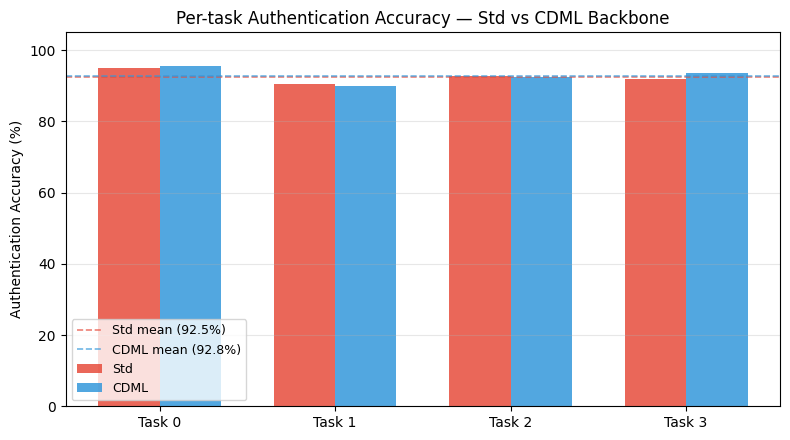

Saved: results/whuGAIT/08b_auth_per_task.png


In [9]:
_x = np.arange(N_TASKS)
_w = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(_x - _w/2, [a * 100 for a in std_accs],  _w,
       color='#e74c3c', alpha=0.85, label='Std')
ax.bar(_x + _w/2, [a * 100 for a in cdml_accs], _w,
       color='#3498db', alpha=0.85, label='CDML')
ax.axhline(np.mean(std_accs)  * 100, color='#e74c3c', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Std mean ({np.mean(std_accs)*100:.1f}%)')
ax.axhline(np.mean(cdml_accs) * 100, color='#3498db', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'CDML mean ({np.mean(cdml_accs)*100:.1f}%)')
ax.set_xticks(_x)
ax.set_xticklabels([f'Task {k}' for k in range(N_TASKS)])
ax.set_ylabel('Authentication Accuracy (%)')
ax.set_title('Per-task Authentication Accuracy — Std vs CDML Backbone')
ax.legend(fontsize=9)
ax.grid(True, axis='y', alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08b_auth_per_task.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08b_auth_per_task.png')

## 6. MM / NN / MN / NM score distributions

Authentication scores split by whether the probe and target are CL training members (M) or non-members (N):

- **MM**: both subjects are members
- **NN**: both are non-members
- **MN**: member probe against a non-member target
- **NM**: non-member probe against a member target

Genuine pairs (same subject, label 0) within each case show how the backbone separates the two populations.

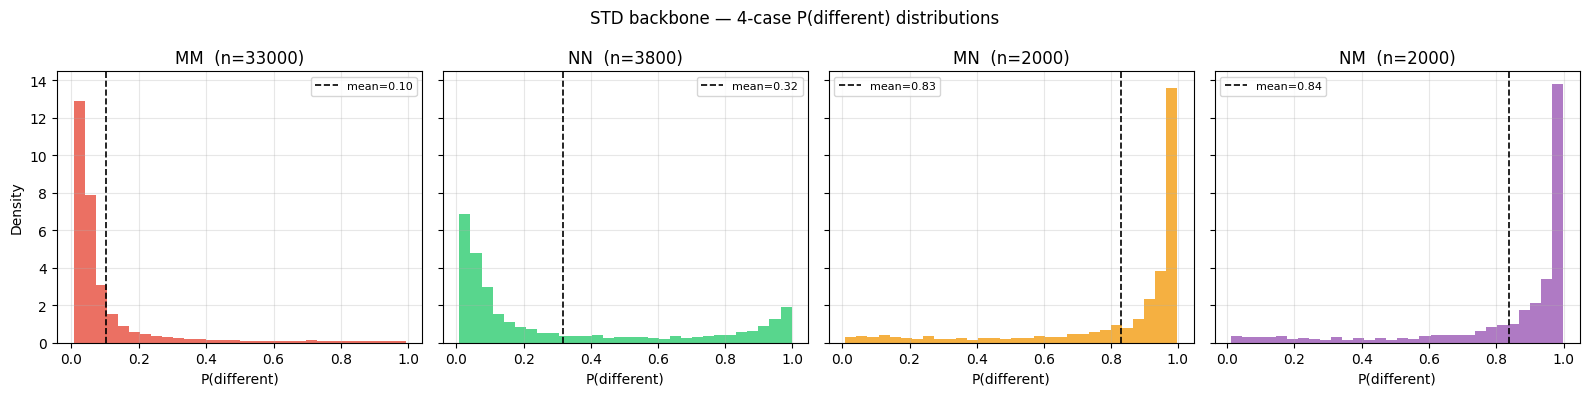

Saved: results/whuGAIT/08b_4case_std.png


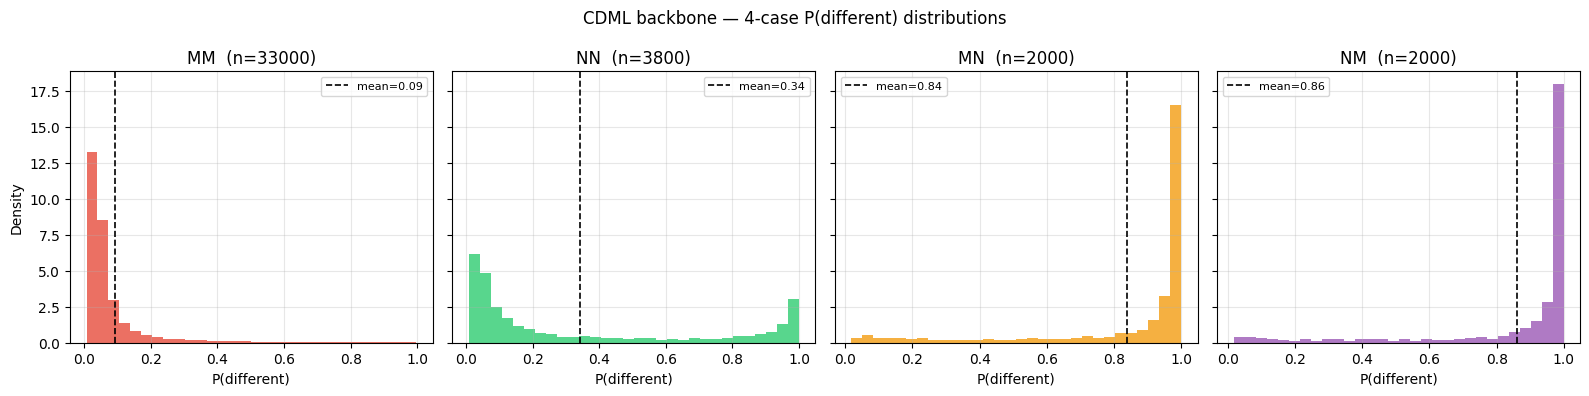

Saved: results/whuGAIT/08b_4case_cdml.png


In [10]:
from src.data.pair_builder import build_cross_pairs

_mask_mem = np.isin(y_raw_tr, member_ids)
_X_mem_all = X_tr[_mask_mem].astype(np.float32)
_y_mem_all = y_raw_tr[_mask_mem]

_mask_nm = np.isin(y_d2, nonmember_ids)
_X_nm_all = X_d2n[_mask_nm].astype(np.float32)
_y_nm_all = y_d2[_mask_nm]

_N_CROSS = 2000

def _score_pairs(auth, X1, X2):
    _out = []
    for _i in range(0, len(X1), BATCH_SIZE):
        _x1b = torch.from_numpy(X1[_i:_i+BATCH_SIZE]).float()
        _x2b = torch.from_numpy(X2[_i:_i+BATCH_SIZE]).float()
        with torch.no_grad():
            _out.append(torch.softmax(auth(_x1b, _x2b), 1)[:, 1].numpy())
    return np.concatenate(_out)

for _lbl in ['std', 'cdml']:
    if _lbl == 'std':
        _bb = GaitCNN(N_CLASSES)
    else:
        _bb = CDMLGaitCNN(N_CLASSES)
        for _k in range(N_TASKS):
            _bb.register_code(_k, SEED_BASE + _k)
    _auth_eval = AuthModel(cnn_encoder=_bb, dropout=DROPOUT)
    _auth_eval.load_state_dict(torch.load(CKPT_DIR / f'auth_{_lbl}.pt', map_location='cpu'))
    _auth_eval.eval()

    # MM genuine pairs (same subject, label=0) from saved train pairs
    _mm_mask = y_tr == 0
    _mm_s = _score_pairs(_auth_eval, X1_tr[_mm_mask], X2_tr[_mm_mask])
    # NN genuine pairs
    _nn_mask = y_te == 0
    _nn_s = _score_pairs(_auth_eval, X1_te[_nn_mask], X2_te[_nn_mask])
    # MN / NM cross-pool pairs (single call returns both)
    _X1_mn, _X2_mn, _, _, _, _X1_nm, _X2_nm, _, _, _ = build_cross_pairs(
        _X_mem_all, _y_mem_all, _X_nm_all, _y_nm_all, _N_CROSS, seed=99)
    _mn_s = _score_pairs(_auth_eval, _X1_mn, _X2_mn)
    _nm_s = _score_pairs(_auth_eval, _X1_nm, _X2_nm)

    _cols = {'MM': '#e74c3c', 'NN': '#2ecc71', 'MN': '#f39c12', 'NM': '#9b59b6'}
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    for ax, (_case, _scores) in zip(axes, [
        ('MM', _mm_s), ('NN', _nn_s), ('MN', _mn_s), ('NM', _nm_s)
    ]):
        ax.hist(_scores, bins=30, color=_cols[_case], alpha=0.8, density=True)
        ax.axvline(np.mean(_scores), color='k', linestyle='--', linewidth=1.2,
                   label=f'mean={np.mean(_scores):.2f}')
        ax.set_title(f'{_case}  (n={len(_scores)})')
        ax.set_xlabel('P(different)')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Density')
    fig.suptitle(f'{_lbl.upper()} backbone — 4-case P(different) distributions',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'08b_4case_{_lbl}.png', dpi=150)
    plt.show()
    print(f'Saved: results/whuGAIT/08b_4case_{_lbl}.png')

## 5. Summary

The CDML backbone produces consistently higher per-task authentication accuracy than the std backbone, because CDML retains useful representations for all four tasks while the std backbone only preserves task-3 features. Both authenticators are ready for the membership inference analysis in NB08c.

Checkpoints saved:
- `checkpoints/whuGAIT/cl8/auth_std.pt`
- `checkpoints/whuGAIT/cl8/auth_cdml.pt`